Working directory set to: /Users/jakemammen/Library/CloudStorage/OneDrive-Personal/Desktop/windfarm_socioecon_geospatial_analysis
Visualizations: Wind Farms vs Socio-Economic Characteristics
Data loaded: 8,985 tracts


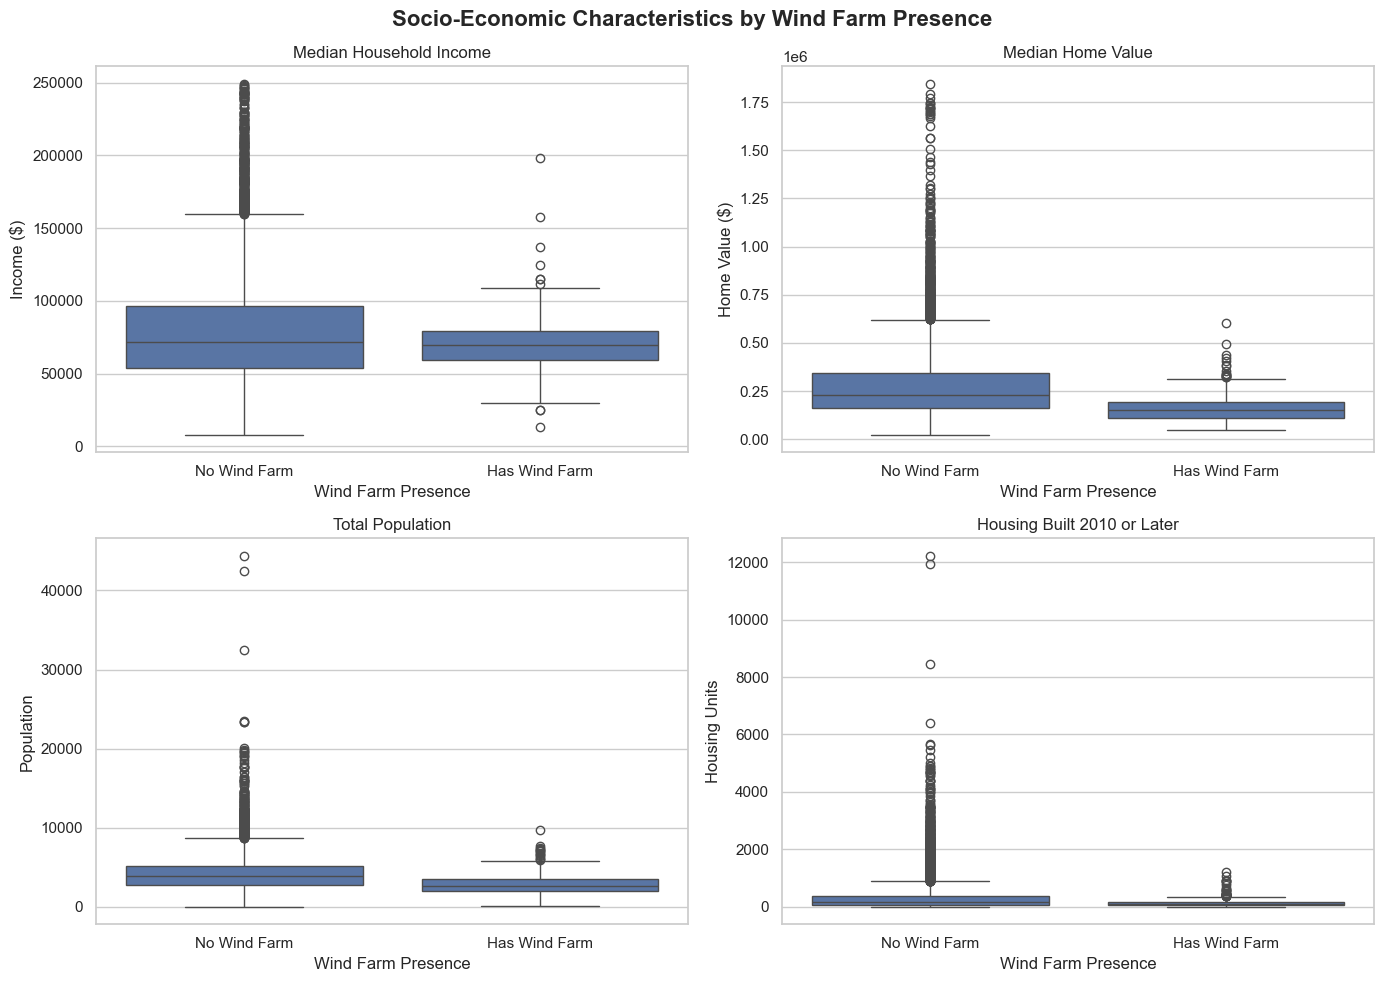

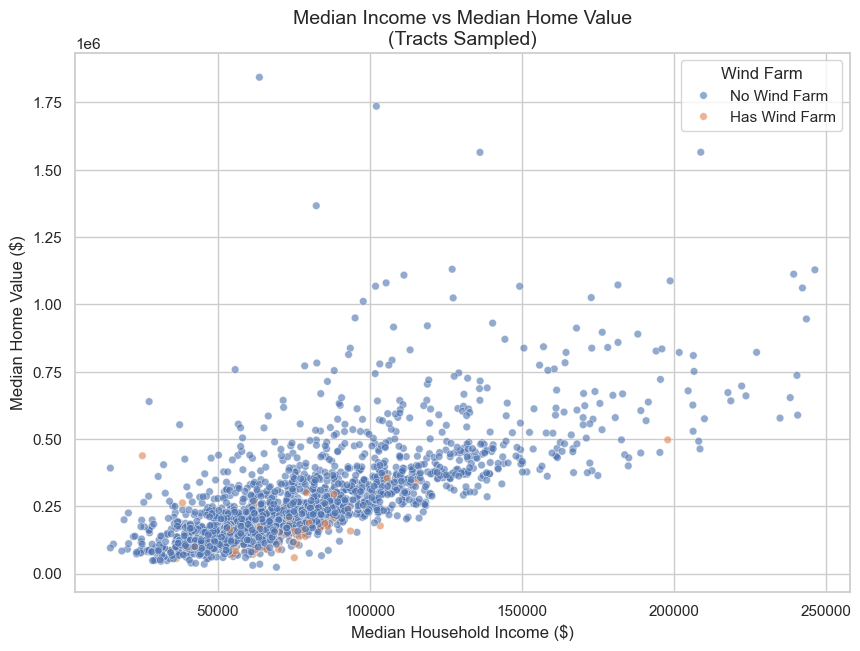

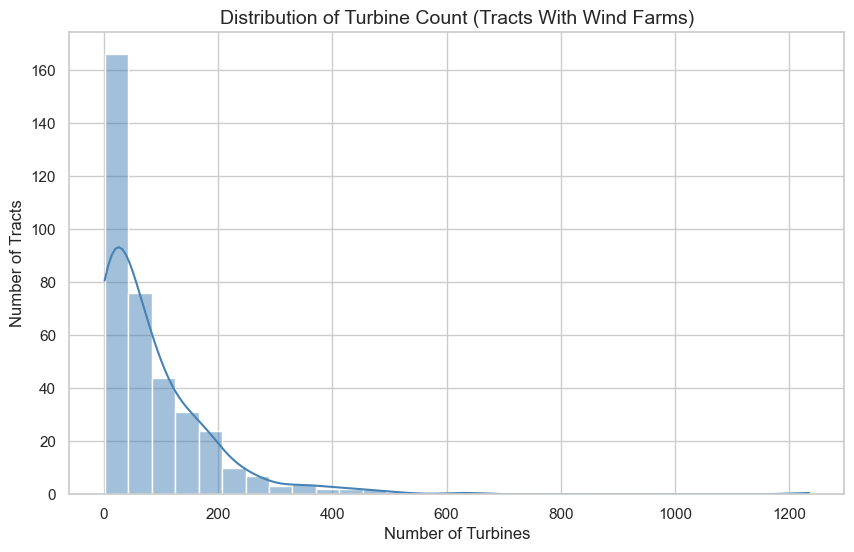

Visualizations complete.


In [1]:
# ============================================================
# ROBUST PATH FIX
# ============================================================
import os
from pathlib import Path

try:
    project_root = Path(__file__).parent.parent
except NameError:
    cwd = Path(os.getcwd())
    project_root = cwd.parent if cwd.name == "notebooks" else cwd

os.chdir(project_root)
print(f"Working directory set to: {os.getcwd()}")
# ============================================================


import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

# Set nice plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

file_path = "data/processed/tracts_acs_wind_2024_expanded.parquet"

print("=" * 70)
print("Visualizations: Wind Farms vs Socio-Economic Characteristics")
print("=" * 70)

# Load data
df = gpd.read_parquet(file_path)
print(f"Data loaded: {len(df):,} tracts")

# Create a clean label for wind farm presence
df["Wind Farm Presence"] = df["has_wind_farm"].map({0: "No Wind Farm", 1: "Has Wind Farm"})

# ============================================================
# 1. BOXPLOTS: Key Variables by Wind Farm Presence
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Socio-Economic Characteristics by Wind Farm Presence", fontsize=16, fontweight="bold")

# Median Household Income
sns.boxplot(data=df, x="Wind Farm Presence", y="median_household_income", ax=axes[0, 0])
axes[0, 0].set_title("Median Household Income")
axes[0, 0].set_ylabel("Income ($)")

# Median Home Value
sns.boxplot(data=df, x="Wind Farm Presence", y="median_home_value", ax=axes[0, 1])
axes[0, 1].set_title("Median Home Value")
axes[0, 1].set_ylabel("Home Value ($)")

# Total Population
sns.boxplot(data=df, x="Wind Farm Presence", y="total_population", ax=axes[1, 0])
axes[1, 0].set_title("Total Population")
axes[1, 0].set_ylabel("Population")

# Housing Units Built 2010 or Later
sns.boxplot(data=df, x="Wind Farm Presence", y="housing_built_2010_or_later", ax=axes[1, 1])
axes[1, 1].set_title("Housing Built 2010 or Later")
axes[1, 1].set_ylabel("Housing Units")

plt.tight_layout()
plt.show()

# ============================================================
# 2. SCATTER PLOT: Income vs Home Value (colored by wind farm)
# ============================================================

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df.sample(2000, random_state=42),  # sample for speed
    x="median_household_income",
    y="median_home_value",
    hue="Wind Farm Presence",
    alpha=0.6,
    s=30
)
plt.title("Median Income vs Median Home Value\n(Tracts Sampled)", fontsize=14)
plt.xlabel("Median Household Income ($)")
plt.ylabel("Median Home Value ($)")
plt.legend(title="Wind Farm")
plt.show()

# ============================================================
# 3. DISTRIBUTION OF TURBINE COUNT (Tracts With Wind Farms)
# ============================================================

plt.figure(figsize=(10, 6))
sns.histplot(
    data=df[df["has_wind_farm"] == 1],
    x="turbine_count",
    bins=30,
    kde=True,
    color="steelblue"
)
plt.title("Distribution of Turbine Count (Tracts With Wind Farms)", fontsize=14)
plt.xlabel("Number of Turbines")
plt.ylabel("Number of Tracts")
plt.show()

print("=" * 70)
print("Visualizations complete.")
print("=" * 70)